In [2]:
import numpy as np
import pandas as pd

In [3]:
##-- Load data
V = pd.read_csv('2019_intercity.csv', header=None).values
M, N = V.shape
K = 3 #------------Change this for number of component 

##-- Settings
max_calnum = 10 #------------ Repeat time
cal_difference = 1e-4 #------------ Change for accuracy
max_iter = 3000  #------------ Change for max iteration

min_differ = 1000
max_differ = -1000

T_cal = np.zeros(max_calnum)
iter_count = np.zeros(max_calnum)
Error = np.zeros(max_calnum)

In [4]:
for rep_calcum in range(max_calnum):

    ##-- Calculation reset
    differ = 1e10
    iteration = 0
    
    ##-- innitiate W&H
    W = np.random.rand(M, K)
    H = np.random.rand(K, N)
    eps = np.finfo(float).eps
    for k in range(K):
            norms = np.linalg.norm(V, axis=0)
            q = np.random.randint(1, N+1)
            ## get indices of largest norms
            max_idx = np.argsort(norms)[-q:]
            s = np.mean(V[:, max_idx])
            W[:, k] = max(eps, s)
        
    ##-- Normalize W
    for k in range(K):
        W[:, k] /= np.linalg.norm(W[:, k])
        # W[:, k] /= np.linalg.norm(W[:, k]) + 1e-12
    
    while differ > cal_difference and iteration < max_iter:
        iteration += 1
        W_tmp = W.copy()

        ##-- Update H
        WtV = W.T @ V
        WtW = W.T @ W
        for k in range(K):
            tmp = WtV[k, :] - (WtW[k, :] @ H) + H[k, :]
            H[k, :] = np.maximum(np.finfo(float).eps, tmp)

        ##-- Update W
        VHt = V @ H.T
        HHt = H @ H.T
        for k in range(K):
            tmp = VHt[:, k] - (W @ HHt[:, k]) + (W[:, k] * HHt[k, k])
            W[:, k] = np.maximum(np.finfo(float).eps, tmp)
            W[:, k] /= np.linalg.norm(W[:, k])
            # W[:, k] /= np.linalg.norm(W[:, k]) + 1e-12

        ## check ngle difference
        tmp_1 = np.sum(W * W_tmp)
        tmp_2 = np.linalg.norm(W, 'fro') * np.linalg.norm(W_tmp, 'fro')
        differ = np.arccos(np.clip(tmp_1 / tmp_2, -1, 1))

    if iteration <= 15:
        continue

    iter_count[rep_calcum] = iteration
    ##-- Evaluate the algorithm

    Error[rep_calcum] = differ

    if rep_calcum == 0:
        min_differ = Error[rep_calcum]
        max_differ = Error[rep_calcum]
        W_Min, H_Min = W.copy(), H.copy()
        W_Max, H_Max = W.copy(), H.copy()
    elif Error[rep_calcum] < min_differ:
        min_differ = Error[rep_calcum]
        W_Min, H_Min = W.copy(), H.copy()
    elif Error[rep_calcum] > max_differ:
        max_differ = Error[rep_calcum]
        W_Max, H_Max = W.copy(), H.copy()


In [5]:
# Normalize H (column-wise)
sum_value = np.sum(H_Min, axis=1, keepdims=True)
H_New = H_Min / sum_value
W_New = W_Min * sum_value.T

In [6]:
##--- Model evaluation information
##--- Error calculation 
E_mat = V - W_New @ H_New
E_date = np.sqrt(np.sum(E_mat**2, axis=0) / M)

base_average = np.tile(np.sum(V, axis=1) / N, (N, 1)).T
base_difference = V - base_average
base_RMSE = np.sqrt(np.sum(base_difference**2, axis=0) / M)

ratio = E_date / np.mean(base_RMSE)
rmse_total = np.sqrt(np.sum(E_mat**2) / (M * N))

# Statistics
iter_count = iter_count[iter_count != 0]
iter_ave = round(np.mean(iter_count))

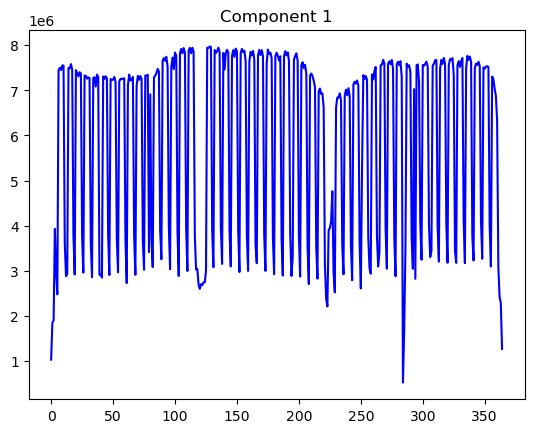

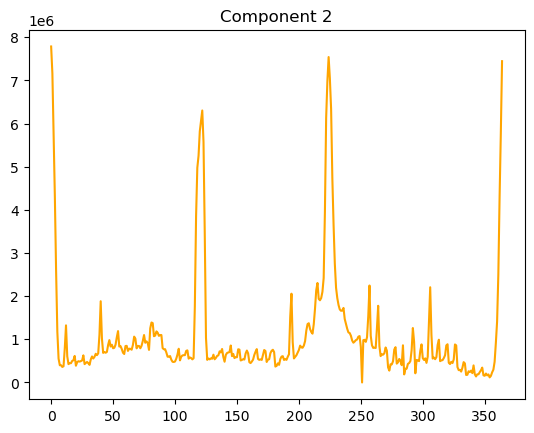

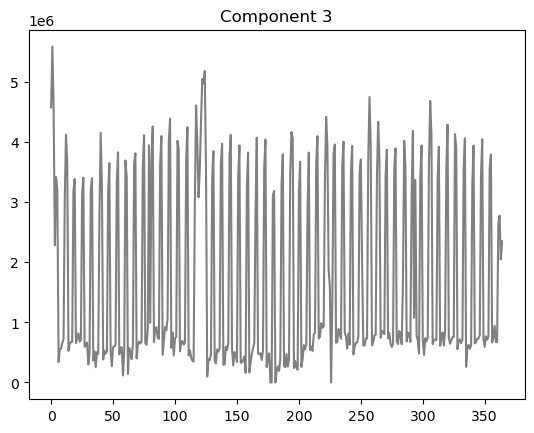

In [11]:
import matplotlib.pyplot as plt
colors = ['blue', 'orange', 'gray','green','red']
for k in range(W_New.shape[1]):
    plt.plot(W_New[:, k], color = colors[k % len(colors)])
    plt.title(f'Component {k+1}')
    plt.savefig(f"output/W_mat_component_{k+1}.png")
    plt.show()
    plt.close()

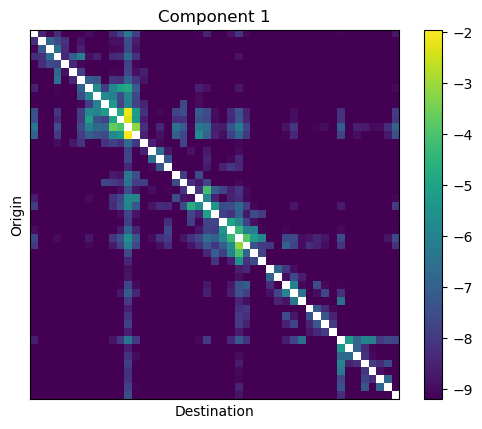

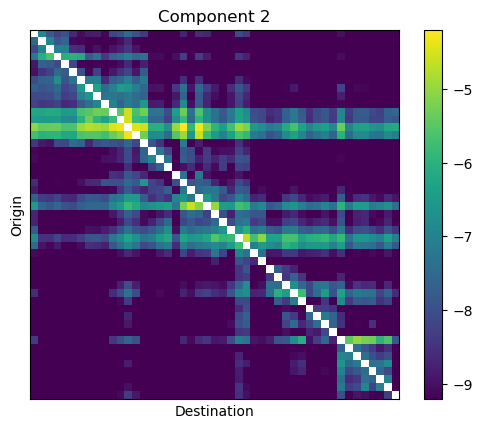

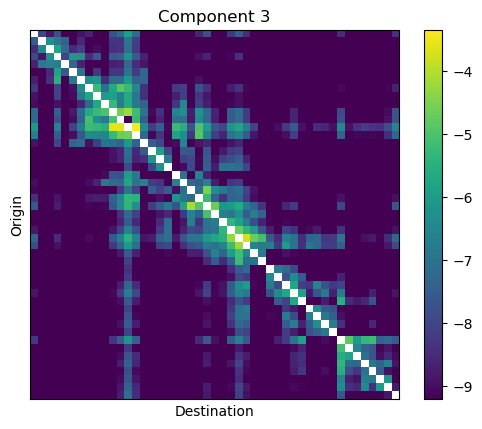

In [13]:
heatmap_size = 47
H_maps = []
tol = 1e-4 #---------------------- Change this

for k in range(H_New.shape[0]):
    H_map = np.zeros((heatmap_size, heatmap_size))
       
    ##-- Fix small values
    H_fix = np.maximum(H_New, tol)

    idx = 0
    for i in range(heatmap_size):
        for j in range(heatmap_size):
            if i != j:
                H_map[i, j] = H_fix[k, idx]
                idx += 1
            else:
                H_map[i, j] = np.nan 
            
    H_map = np.log(H_map)
    H_maps.append(H_map)
    
for k in range(len(H_maps)):
    plt.figure()
    plt.imshow(H_maps[k])
    plt.colorbar()
    plt.title(f'Component {k+1}')
    plt.xlabel('Destination')
    plt.ylabel('Origin')
    plt.xticks([])
    plt.yticks([])
    plt.savefig(f"output/H_mat_component_{k+1}.png")
    plt.show()
    plt.close()